In [1]:
import config as config

In [2]:
import os
import warnings
import math
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from datetime import datetime
import plotly as py
import plotly.graph_objects as go
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, Callback

In [3]:
# STEP 1: Load Data File
path = 'Downloads/Individual Household Electric Power Consumption/household_power_consumption/household_power_consumption.txt'

dtypes = {'Date': str,
          'Time': str,
          'Global_active_power': float,
          'Global_reactive_power': float,
          'Voltage': float,
          'Global_intensity': float,
          'Sub_metering_1': float,
          'Sub_metering_2': float,
          'Sub_metering_3': float}

hh_pwr_consum = pd.read_csv(path, sep=';', dtype=dtypes, na_values='?')
print("Dataset loaded successfully")
print(f"Initial dataset shape: {hh_pwr_consum.shape}")


Dataset loaded successfully
Initial dataset shape: (2075259, 9)


In [4]:
hh_pwr_consum['DateTime'] = pd.to_datetime(hh_pwr_consum['Date'] + ' ' + hh_pwr_consum['Time'], dayfirst=True)
hh_pwr_consum.set_index('DateTime', inplace=True)
hh_pwr_consum.drop(columns=['Date', 'Time'], inplace=True)
print("DateTime column created and set as index")

DateTime column created and set as index


In [5]:
print("Missing values before cleaning:", hh_pwr_consum.isna().sum().sum())

Missing values before cleaning: 181853


In [6]:
for col in hh_pwr_consum.columns:
    hh_pwr_consum[col] = pd.to_numeric(hh_pwr_consum[col], errors='coerce')


In [7]:
hh_pwr_consum.interpolate(method='linear', inplace=True)
hh_pwr_consum.ffill(inplace=True) 

print("Missing values after interpolation and forward fill:")
print(hh_pwr_consum.isna().sum())

Missing values after interpolation and forward fill:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [8]:
duplicates = hh_pwr_consum.duplicated().sum()
print("Duplicates found:", duplicates)
hh_pwr_consum = hh_pwr_consum[~hh_pwr_consum.index.duplicated(keep='first')]
print(f"Dataset shape after removing duplicates: {hh_pwr_consum.shape}")


Duplicates found: 142582
Dataset shape after removing duplicates: (2075259, 7)


In [9]:
print("Final dataframe info:")
print(hh_pwr_consum.info())
print(hh_pwr_consum.head())


Final dataframe info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 191.2 MB
None
                     Global_active_power  Global_reactive_power  Voltage  \
DateTime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-1

In [10]:
hh_pwr_consum['Year'] = hh_pwr_consum.index.year
hh_pwr_consum['Month'] = hh_pwr_consum.index.month
hh_pwr_consum['Day'] = hh_pwr_consum.index.weekday  # Monday=0
hh_pwr_consum['Hour'] = hh_pwr_consum.index.hour

In [11]:
hh_pwr_consum_univariate = hh_pwr_consum[['Global_active_power', 'Year', 'Month', 'Day', 'Hour']]

In [12]:
pd.options.display.float_format = '{:.8f}'.format  
np.round(hh_pwr_consum['Global_active_power'].describe(), 8)

count   2075259.00000000
mean          1.09027954
std           1.05262800
min           0.07600000
25%           0.31000000
50%           0.61400000
75%           1.52800000
max          11.12200000
Name: Global_active_power, dtype: float64

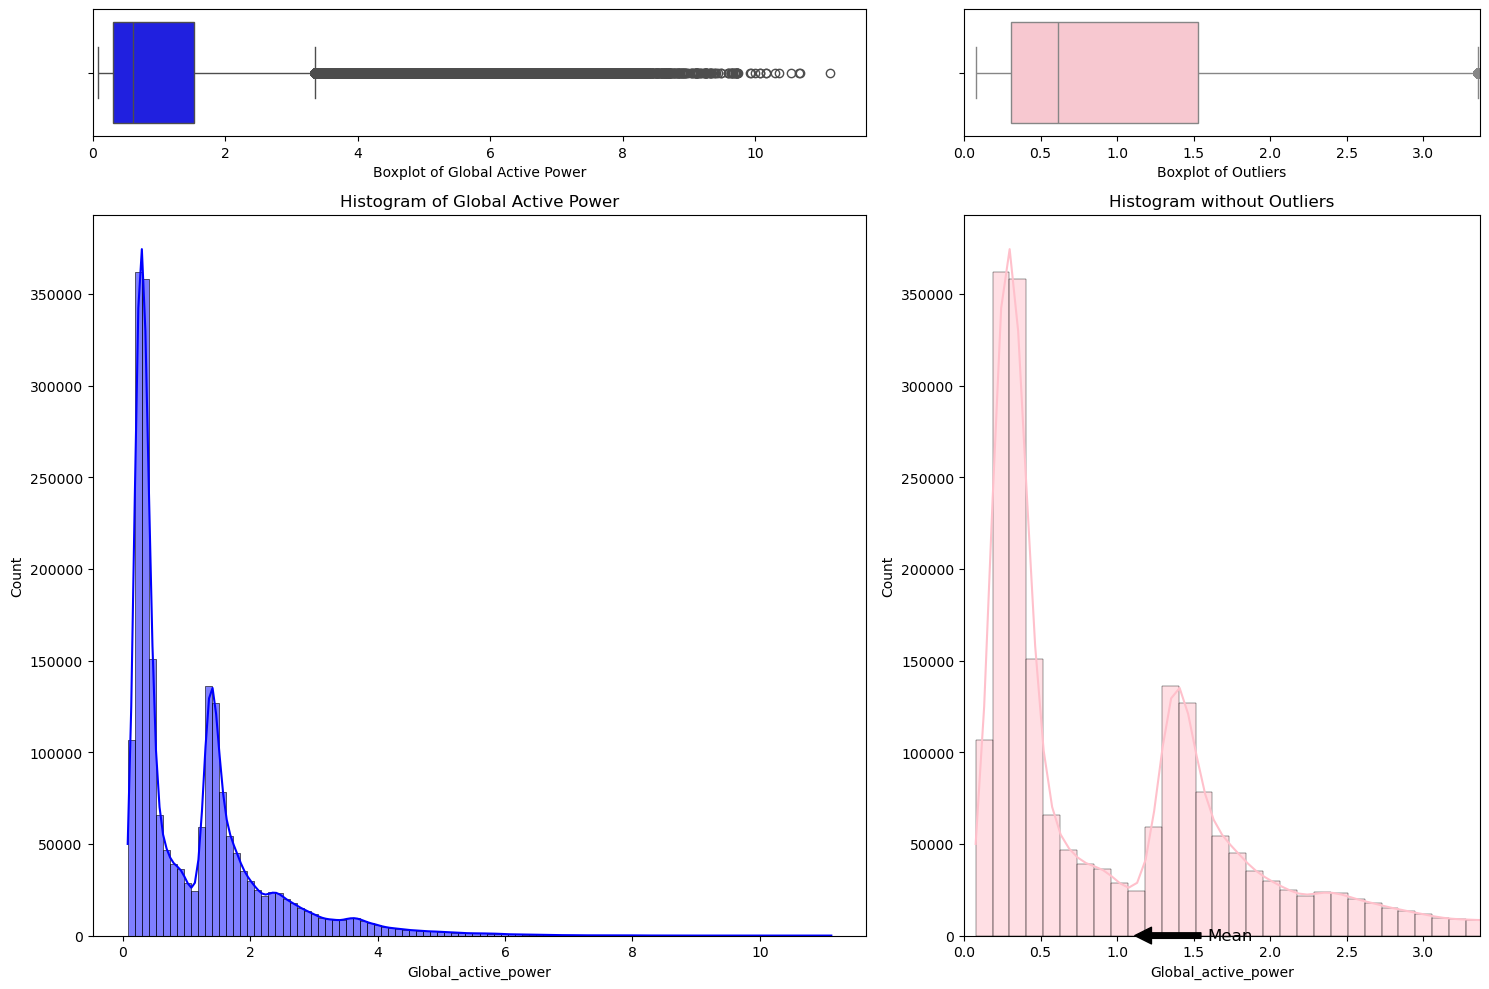

In [13]:
# Create subplots with your custom grid size and ratios
f, axes = plt.subplots(2, 2, figsize=(15, 10), 
                       sharex=False, 
                       gridspec_kw={"height_ratios": (.15, .85), "width_ratios": (.60, .40)})


# main boxplot (top-left)
sns.boxplot(x=hh_pwr_consum['Global_active_power'], color="blue", ax=axes[0, 0])
axes[0, 0].set_xlabel('Boxplot of Global Active Power') 
axes[0, 0].set_xlim(0, None)

# zoom boxplot (top-right)
sns.boxplot(x=hh_pwr_consum['Global_active_power'], color="pink", ax=axes[0, 1])
axes[0, 1].set_xlabel('Boxplot of Outliers') 
axes[0, 1].set_xlim(0, 3.37) 

# main histogram (bottom-left)
sns.histplot(hh_pwr_consum['Global_active_power'], color="blue", bins=100, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Histogram of Global Active Power')

# zoom histogram (bottom-right)
sns.histplot(hh_pwr_consum['Global_active_power'], color="pink", bins=100, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Histogram without Outliers')
axes[1, 1].set_xlim(0, 3.37)

# Add an arrow to mark the mean value
axes[1,1].annotate(
    'Mean', 
    xy=(hh_pwr_consum["Global_active_power"].mean(), 0.15), 
    xytext=(hh_pwr_consum["Global_active_power"].mean() + 0.5, 0.8),
    arrowprops=dict(facecolor='black', shrink=0.05),
    fontsize=12,
    horizontalalignment='left',
    verticalalignment='center'
)

plt.tight_layout()
plt.show()


Question: How does average power usage vary by hour of the day, and how has this pattern changed year-to-year?

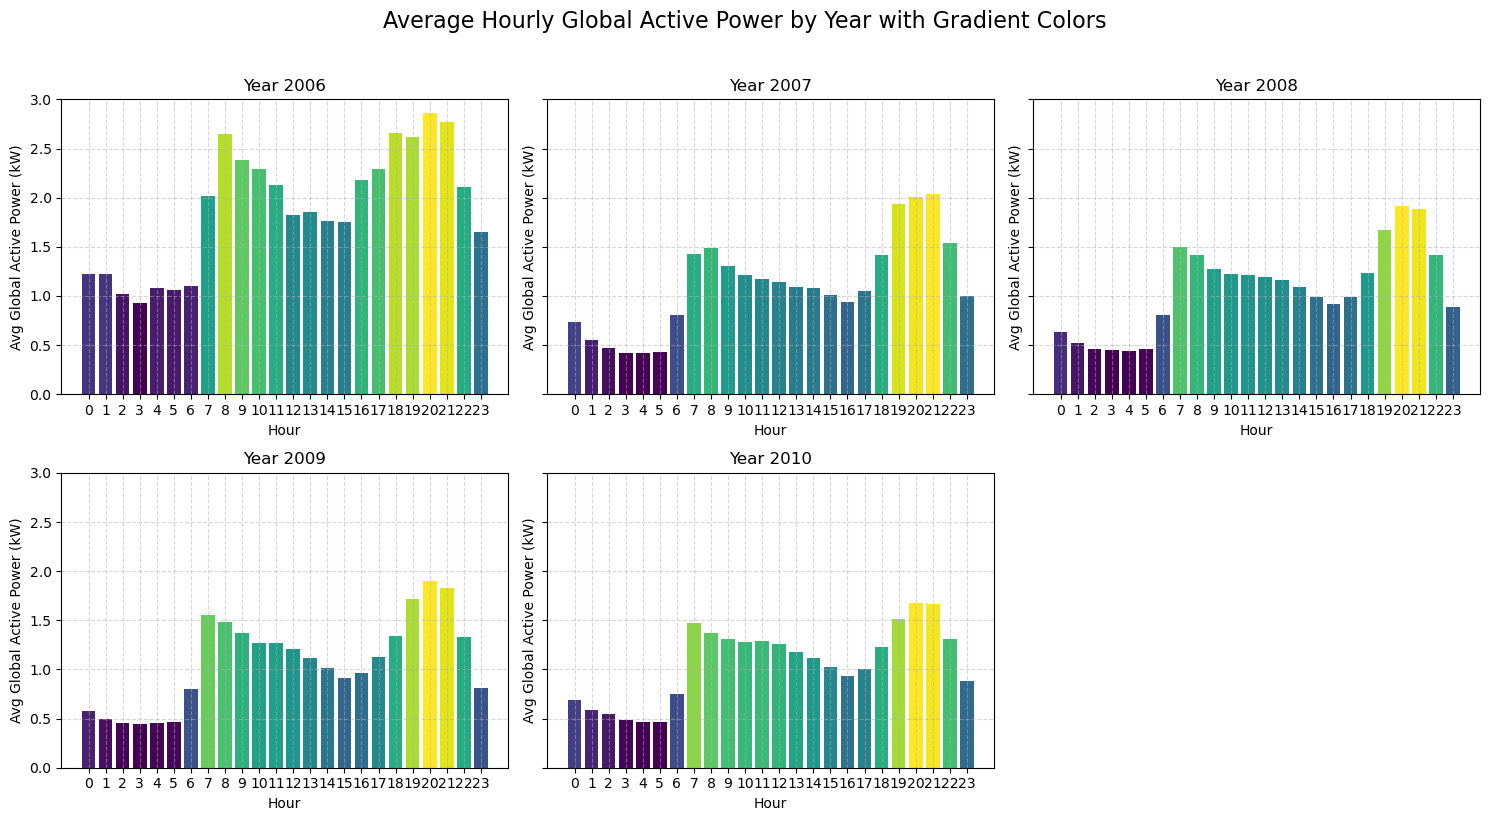

In [15]:
hourly_avg_year = hh_pwr_consum.groupby(['Year', 'Hour'])['Global_active_power'].mean().reset_index()

years = hourly_avg_year['Year'].unique()
n_cols = 3
n_rows = int(np.ceil(len(years) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4), sharey=True)
axes = axes.flatten()

for i, year in enumerate(sorted(years)):
    ax = axes[i]
    data = hourly_avg_year[hourly_avg_year['Year'] == year]
    
    norm = plt.Normalize(data['Global_active_power'].min(), data['Global_active_power'].max())
    colors = cm.viridis(norm(data['Global_active_power'])) 
    
    bars = ax.bar(data['Hour'], data['Global_active_power'], color=colors)
    
    ax.set_title(f'Year {year}')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Avg Global Active Power (kW)')
    ax.set_xticks(range(0, 24))
    ax.grid(True, linestyle='--', alpha=0.5)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Average Hourly Global Active Power by Year with Gradient Colors', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


Question: How does power usage change between Winter, Spring, Summer, and Autumn each year?

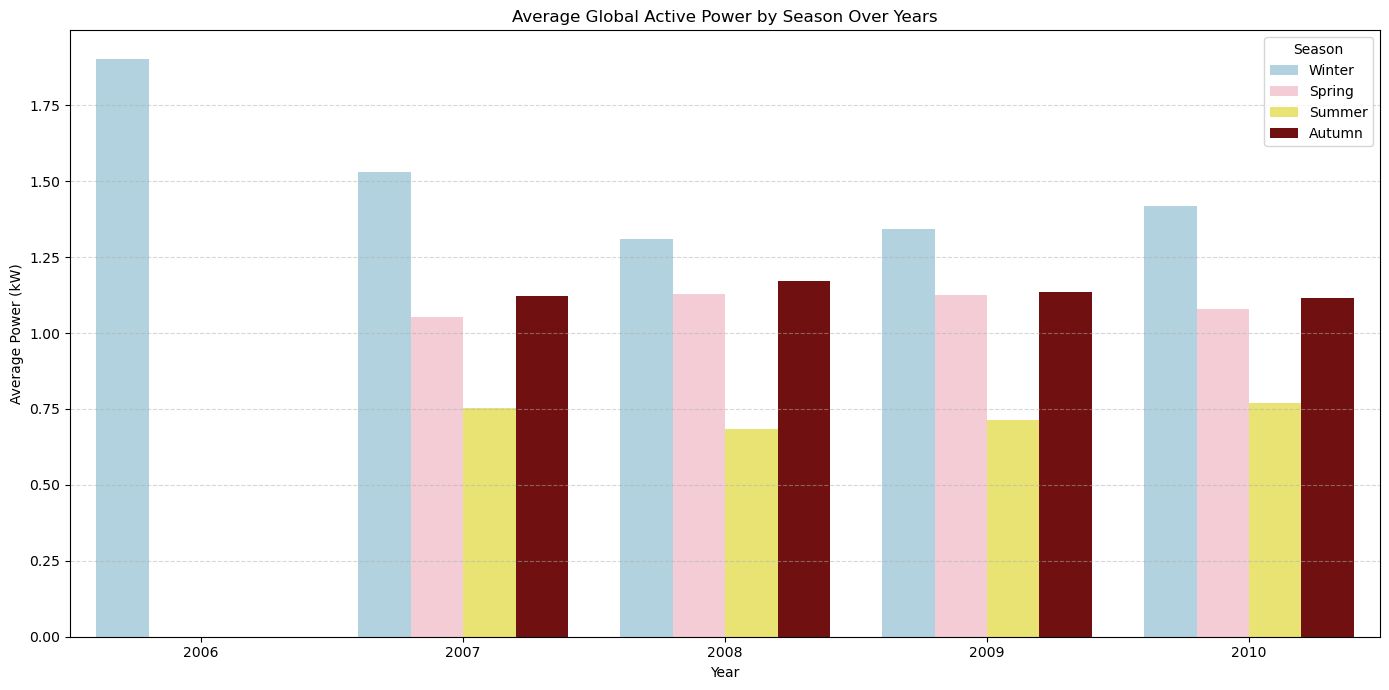

In [17]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

hh_pwr_consum['Season'] = hh_pwr_consum['Month'].apply(month_to_season)

seasonal_avg_year = hh_pwr_consum.groupby(['Year', 'Season'])['Global_active_power'].mean().reset_index()

custom_palette = {
    'Summer': '#FCF55F',        
    'Winter': '#A9D6E5',        
    'Autumn': '#800000',        
    'Spring': '#F9C6D3'         
}

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
seasonal_avg_year['Season'] = pd.Categorical(seasonal_avg_year['Season'], categories=season_order, ordered=True)

plt.figure(figsize=(14,7))
sns.barplot(
    data=seasonal_avg_year,
    x='Year',
    y='Global_active_power',
    hue='Season',
    hue_order=season_order,
    palette=custom_palette,
    errorbar=None
)
plt.title('Average Global Active Power by Season Over Years')
plt.xlabel('Year')
plt.ylabel('Average Power (kW)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

Question:"What are the monthly trends in power usage, including median and peak values? How do they vary across years?"
(Look at seasonal patterns + extremes + yearly comparison)

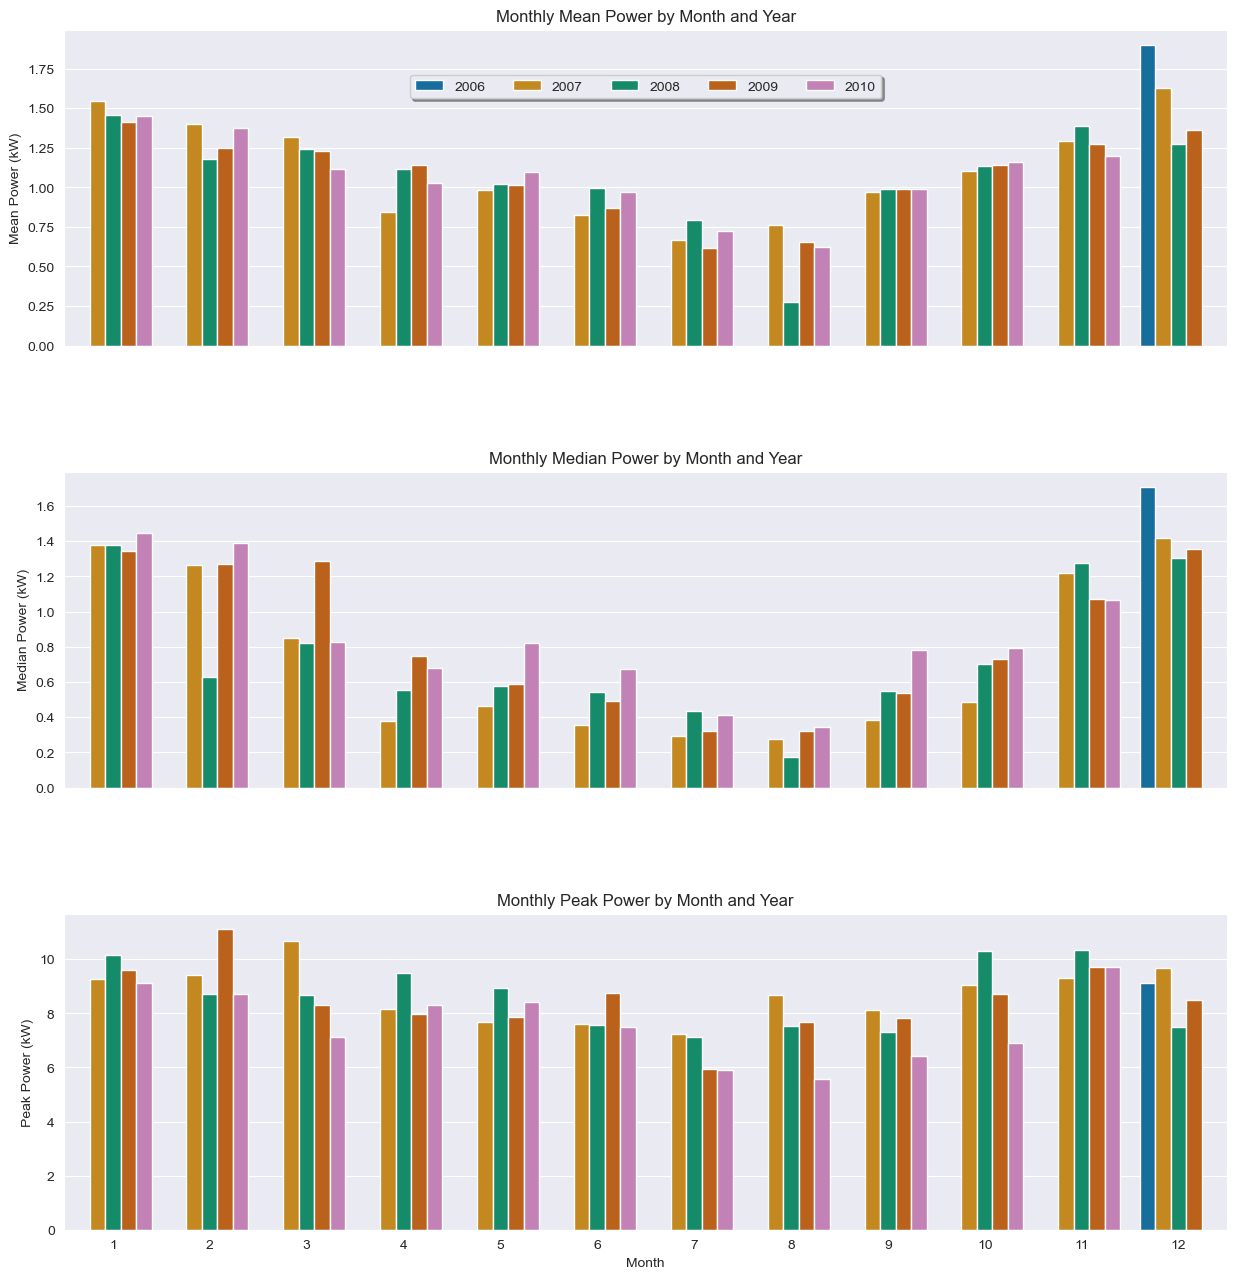

In [19]:
hh_pwr_consum_monthly_summary = hh_pwr_consum.groupby(['Year', 'Month'])['Global_active_power'] \
    .agg(['mean', 'median', 'max']).reset_index()

# Rename columns for easier plotting
hh_pwr_consum_monthly_summary.rename(columns={
    'mean': 'mean_power',
    'median': 'median_power',
    'max': 'max_power'
}, inplace=True)


sns.set_style("darkgrid")
f, axes = plt.subplots(3, figsize=(15, 16), sharex=True)

sns.barplot(x='Month', y='mean_power', hue='Year', data=hh_pwr_consum_monthly_summary,
            palette="colorblind", ax=axes[0], errorbar=None)
axes[0].set_title('Monthly Mean Power by Month and Year')
axes[0].set_ylabel('Mean Power (kW)')
axes[0].legend_.remove()

sns.barplot(x='Month', y='median_power', hue='Year', data=hh_pwr_consum_monthly_summary,
            palette="colorblind", ax=axes[1], errorbar=None)
axes[1].set_title('Monthly Median Power by Month and Year')
axes[1].set_ylabel('Median Power (kW)')
axes[1].legend_.remove()

sns.barplot(x='Month', y='max_power', hue='Year', data=hh_pwr_consum_monthly_summary,
            palette="colorblind", ax=axes[2], errorbar=None)
axes[2].set_title('Monthly Peak Power by Month and Year')
axes[2].set_ylabel('Peak Power (kW)')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, 3.68), shadow=True, ncol=5)

plt.xlabel('Month')
plt.subplots_adjust(top=0.9, bottom=0.15, hspace=0.4)
plt.show()

In [20]:
print(hh_pwr_consum.index.name) 

DateTime


In [21]:
#Partitioning Series based on year, with 2006-2009 in the train set and 2010 in the test set.

indexed_hh_pwr_consum = hh_pwr_consum[['Global_active_power', 'Year', 'Month']]
train = indexed_hh_pwr_consum[indexed_hh_pwr_consum['Year'] < 2010] #train set is years 2006 - 2009
test = indexed_hh_pwr_consum[indexed_hh_pwr_consum['Year'] == 2010] #test set is year 2010

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm
train_monthly=train[['Global_active_power']].resample('W').mean()
mod = SARIMAX(train_monthly, order=(1, 1, 1),
                                seasonal_order=(1, 1, 0, 50), #50 = number of weeks that we are forcasting
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results = mod.fit()

In [23]:
results.forecast()

2010-01-10   1.28152477
Freq: W-SUN, dtype: float64

In [24]:
predictions = results.predict(start='2010-01-03', end='2010-12-19')

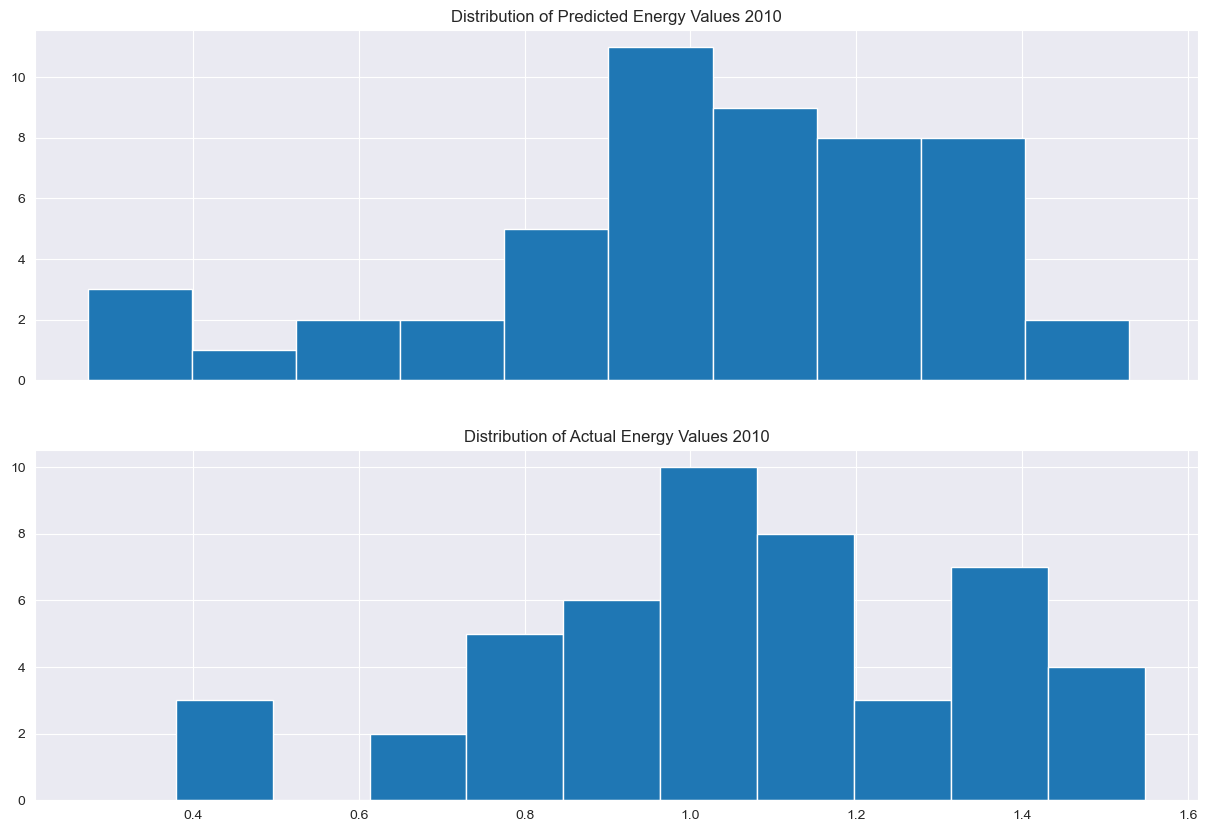

In [25]:
#Evaluate performance
# predictions.index
f, axes = plt.subplots(2, figsize=(15, 10), sharex=True)
axes[0].hist(predictions.values, bins=10)
axes[0].set_title("Distribution of Predicted Energy Values 2010")
axes[1].hist((test[['Global_active_power']].resample('W').mean().values), bins=10)
axes[1].set_title("Distribution of Actual Energy Values 2010")
plt.show()

In [26]:
#merge on DateTime
actual = test[['Global_active_power']].resample('W').mean().reset_index()
actual.rename(columns={'DateTime': 'DateTime'}, inplace=True)  # rename if necessary

prediction = pd.DataFrame(predictions).reset_index()
prediction.columns = ['DateTime', 'Global_active_power']

res = pd.merge(actual, prediction, 
               how='left', 
               on='DateTime')

res.columns = ['DateTime', 'actual', 'predictions']
res['residuals'] = res['actual'] - res['predictions']
res.head()


,DateTime,actual,predictions,residuals
0,2010-01-03,1.06933356,1.52876168,-0.45942811
1,2010-01-10,1.39018929,1.28152477,0.10866452
2,2010-01-17,1.50472837,1.35630512,0.14842325
3,2010-01-24,1.53529534,1.33522315,0.20007219
4,2010-01-31,1.54802817,1.02054673,0.52748144


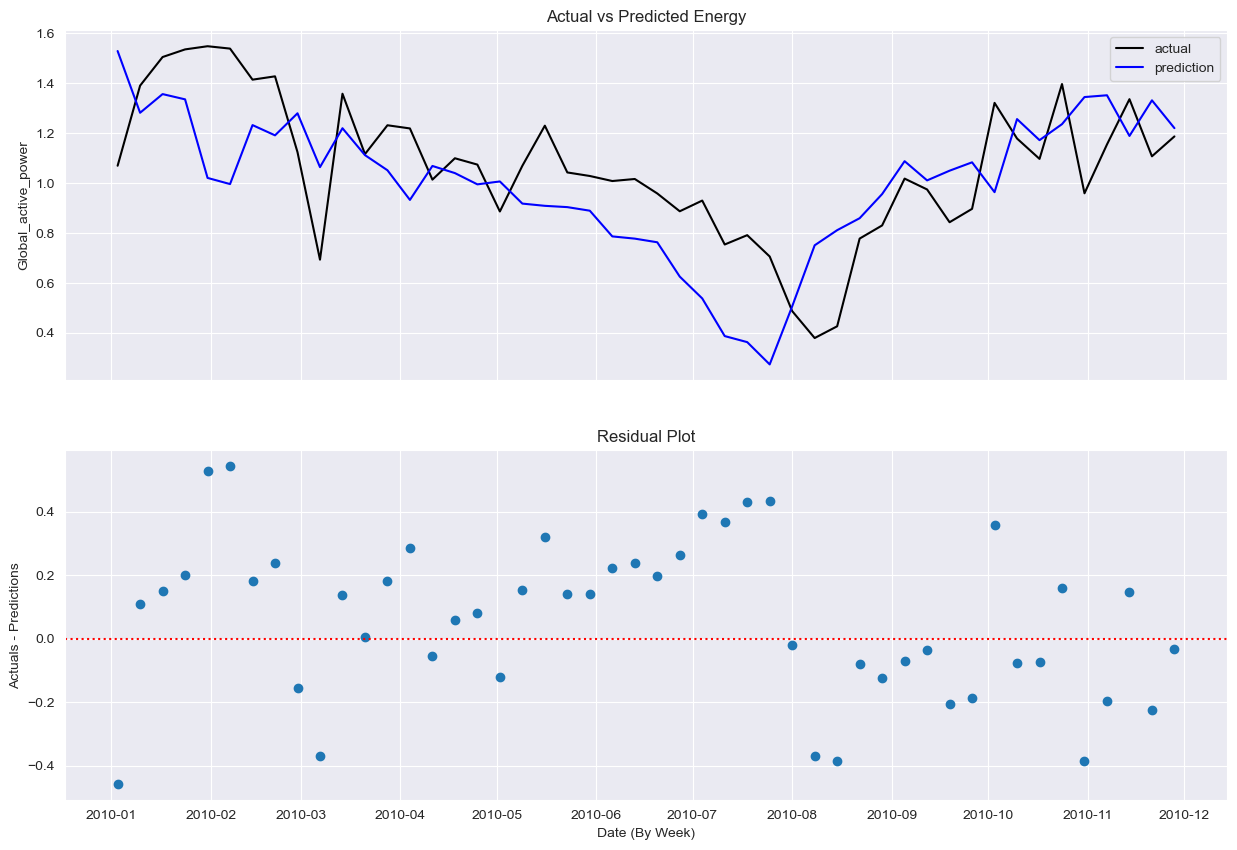

MSE =  0.06507467944785983


In [27]:
f, axes = plt.subplots(2, figsize=(15, 10), sharex=True)

#plot of actual vs predictions
axes[0].plot(res['DateTime'],res['actual'], color='black', label='actual')
axes[0].plot(res['DateTime'],res['predictions'], color='blue', label='prediction')
axes[0].set_title('Actual vs Predicted Energy')
axes[0].set_ylabel('Global_active_power')
axes[0].legend()

#plot of actual - predictions
axes[1].scatter(res['DateTime'],(res['actual'] - res['predictions']))
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Date (By Week)')
axes[1].set_ylabel('Actuals - Predictions')
axes[1].axhline(y=0, color='r', linestyle=':')

plt.show()

#MSE
print("MSE = ", np.mean(res['residuals']**2)) #MSE

In [28]:
# Multivariate Feature Engineering ---
# Lag features (important temporal context)
hh_pwr_consum['lag_1'] = hh_pwr_consum['Global_active_power'].shift(1)       # previous minute
hh_pwr_consum['lag_60'] = hh_pwr_consum['Global_active_power'].shift(60)     # approx previous hour
hh_pwr_consum['rolling_mean_60'] = hh_pwr_consum['Global_active_power'].rolling(window=60).mean()

In [29]:
# Drop NaNs created by lag/rolling operations
hh_pwr_consum.dropna(inplace=True)

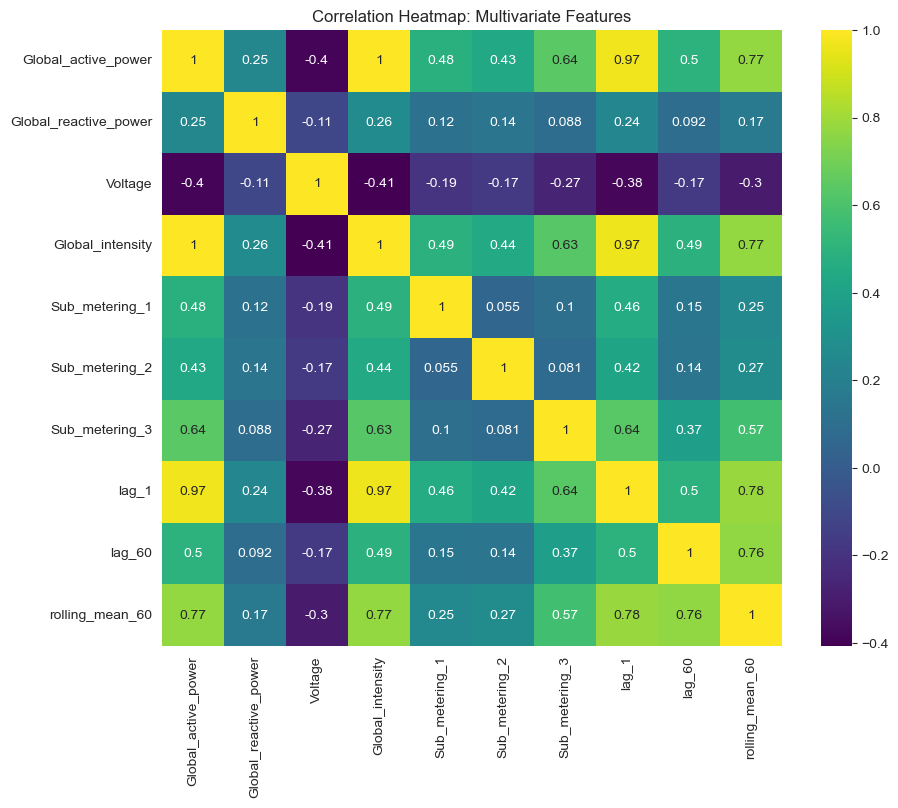

In [30]:
# --- STEP 2: Multivariate Exploratory Data Analysis (EDA) ---

# Correlation heatmap of main features
corr_cols = [
    'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
    'lag_1', 'lag_60', 'rolling_mean_60'
]

plt.figure(figsize=(10, 8))
sns.heatmap(hh_pwr_consum[corr_cols].corr(), annot=True, cmap='viridis')
plt.title('Correlation Heatmap: Multivariate Features')
plt.show()

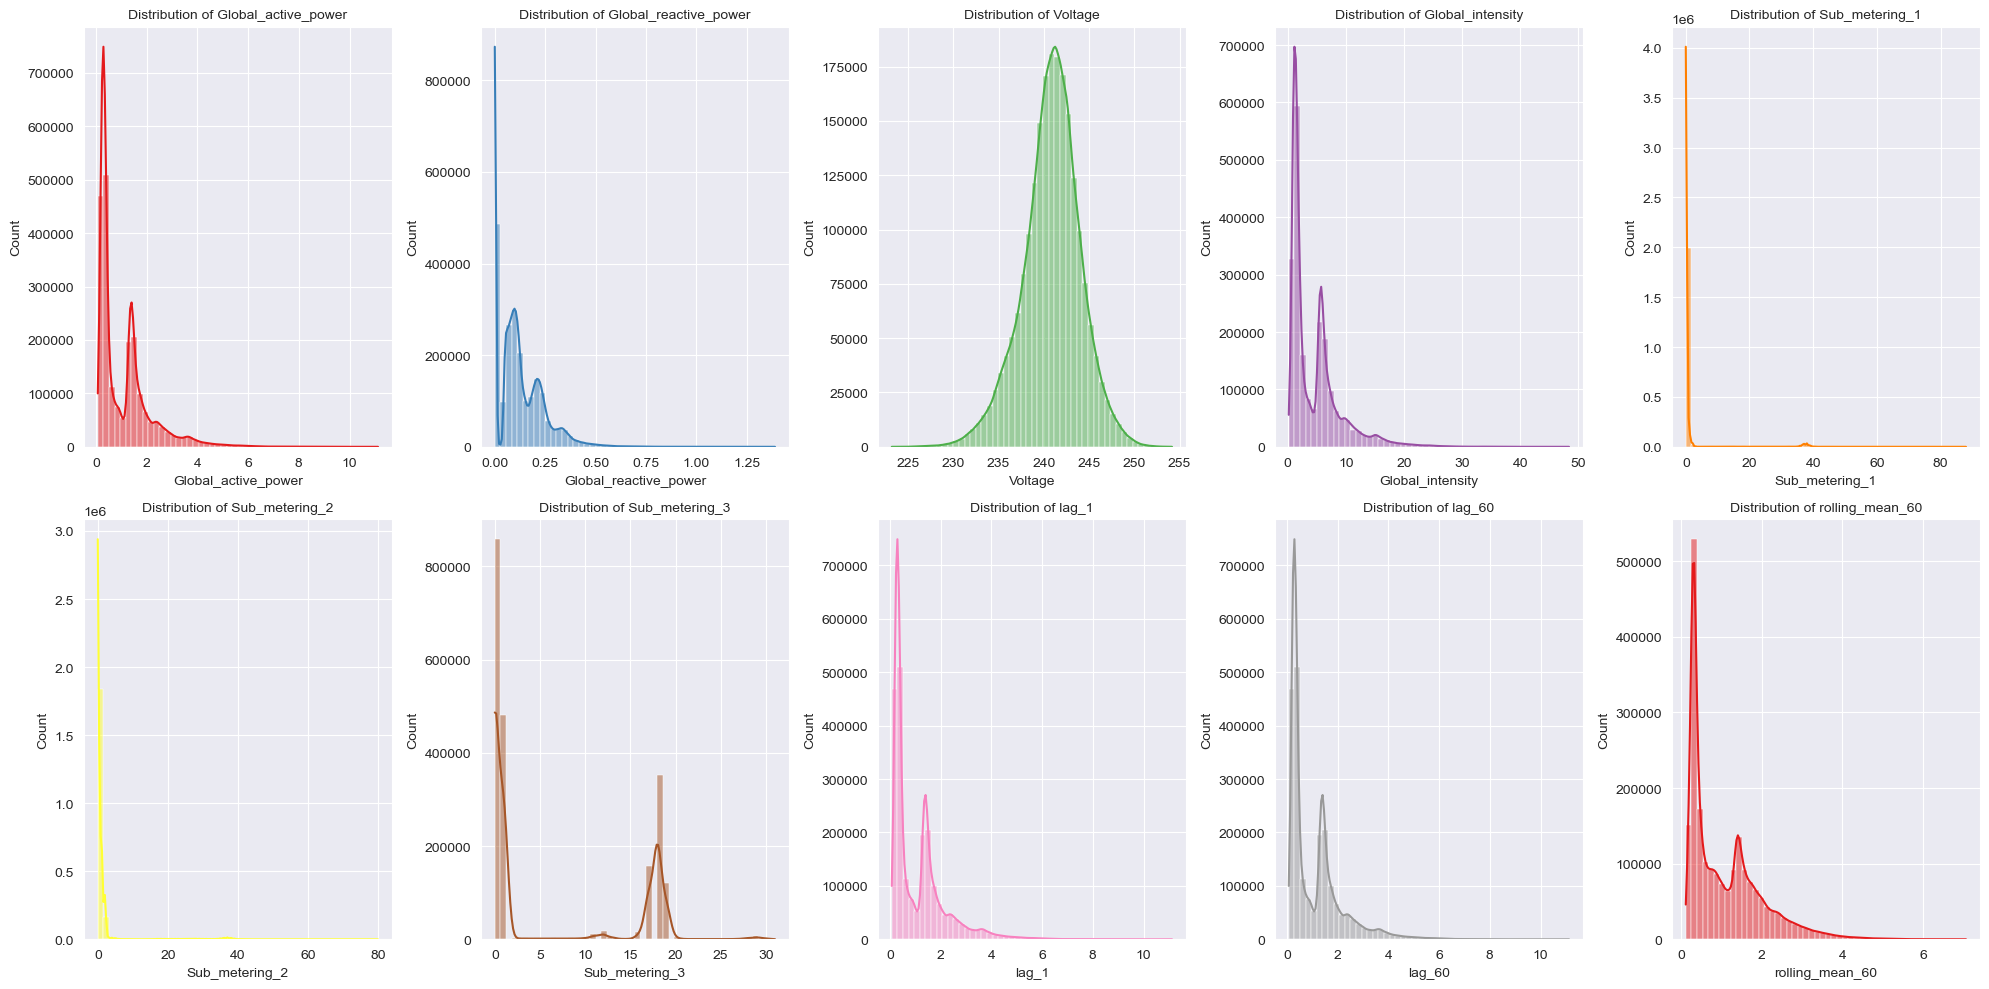

In [31]:
numeric_feats = corr_cols.copy()
n = len(numeric_feats)
cols = 5
rows = (n + cols - 1) // cols

colors = sns.color_palette("Set1", n_colors=n)

fig, axes = plt.subplots(rows, cols, figsize=(20, 10))  # wider and shorter for compact layout
axes = axes.flatten()

for i, col in enumerate(numeric_feats):
    sns.histplot(hh_pwr_consum[col], bins=50, ax=axes[i], kde=True, color=colors[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=10)

# Hide unused subplots (in case less than rows*cols)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [32]:
# Anomaly detection on Global_active_power using Isolation Forest
iso_forest = IsolationForest(contamination=0.01, random_state=42)
hh_pwr_consum['anomaly'] = iso_forest.fit_predict(hh_pwr_consum[['Global_active_power']])

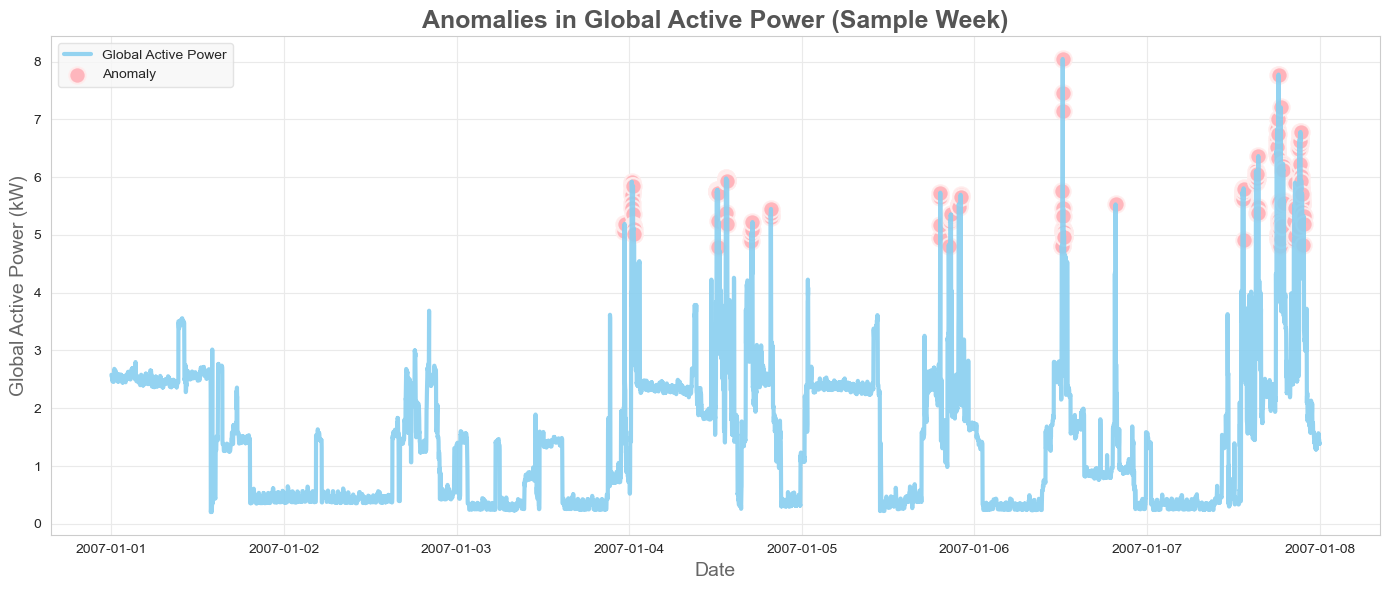

In [33]:
# Select a valid week
sample_hh_pwr_consum = hh_pwr_consum.loc['2007-01-01':'2007-01-07']

sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

# Pastel main line (soft blue)
plt.plot(
    sample_hh_pwr_consum.index,
    sample_hh_pwr_consum['Global_active_power'],
    label="Global Active Power",
    color="#89CFF0",         # pastel baby blue
    linewidth=3,
    alpha=0.9
)

# Extract anomalies
anomalies = sample_hh_pwr_consum[sample_hh_pwr_consum['anomaly'] == -1]

# Pastel red/pink anomalies with soft edges
plt.scatter(
    anomalies.index,
    anomalies['Global_active_power'],
    color="#FFB3BA",         # pastel pink
    s=140,
    edgecolor="#FFEDED",     # very soft white-pink border
    linewidth=1.5,
    label="Anomaly",
    alpha=0.95
)

# Titles + labels in soft gray
plt.title("Anomalies in Global Active Power (Sample Week)", fontsize=18, weight="bold", color="#555")
plt.xlabel("Date", fontsize=14, color="#666")
plt.ylabel("Global Active Power (kW)", fontsize=14, color="#666")

# Soft pastel grid lines
plt.grid(color="#EAEAEA")

# Legend with pastel background
plt.legend(facecolor="#F7F7F7", edgecolor="#DDD")

plt.tight_layout()
plt.show()


In [34]:
#Define features to use for modeling (exclude Season and target)
features = [col for col in hh_pwr_consum.columns if col not in ['Global_active_power', 'Season', 'anomaly']]

#Create a modeling dataframe without 'Season'
df_model = hh_pwr_consum[features].copy()

#Scale numeric features (only those in corr_cols that are present in df_model)
features_to_scale = [f for f in features if f in corr_cols]  

scaler = MinMaxScaler()
df_model[features_to_scale] = scaler.fit_transform(df_model[features_to_scale])

In [35]:
# Target
y = hh_pwr_consum['Global_active_power']

# Time-based train-test split (80%-20%)
split_index = int(len(hh_pwr_consum) * 0.8)
X_train, X_test = df_model.iloc[:split_index], df_model.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1660159, 13)
Test shape: (415040, 13)


In [36]:
#Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
r2 = r2_score(y_test, y_pred_rf)
print(f"Random Forest R^2: {r2:.4f}")

#If relative MAE is below 1-2%, that’s usually quite good
mean_target = y_test.mean()
print("Mean Global Active Power (Test):", mean_target)
relative_mae = (mean_absolute_error(y_test, y_pred_rf) / mean_target) * 100
print(f"Relative MAE: {relative_mae:.4f}%")


Random Forest MAE: 0.016970089319078258
Random Forest RMSE: 0.03235835491773753
Random Forest R^2: 0.9986
Mean Global Active Power (Test): 1.003263189090208
Relative MAE: 1.6915%


In [37]:
#LSTM Model Preparation 

def create_sequences(X, y, time_steps=60):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:(i + time_steps)].values)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 60  # Use past hour data (60 minutes) for prediction

X_lstm, y_lstm = create_sequences(df_model, y, time_steps)

# Train-test split
split_lstm = int(X_lstm.shape[0]*0.8)
X_train_lstm, X_test_lstm = X_lstm[:split_lstm], X_lstm[split_lstm:]
y_train_lstm, y_test_lstm = y_lstm[:split_lstm], y_lstm[split_lstm:]


In [38]:
model = Sequential()
model.add(Input(shape=(time_steps, X_train_lstm.shape[2])))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

try:
    history = model.fit(
        X_train_lstm, y_train_lstm,
        epochs=25,
        batch_size=64,
        validation_data=(X_test_lstm, y_test_lstm),
        callbacks=[early_stopping]
    )

    if early_stopping.stopped_epoch > 0:
        print(f"\nEarly stopping triggered at epoch {early_stopping.stopped_epoch + 1}.\n")

except KeyboardInterrupt:
    print("Training interrupted manually. Moving on...")


Epoch 1/25
25940/25940 ━━━━━━━━━━━━━━━━━━━━ 1361s 52ms/step - loss: 1.2070 - val_loss: 0.7806
Epoch 2/25
25940/25940 ━━━━━━━━━━━━━━━━━━━━ 3329s 128ms/step - loss: 1.1899 - val_loss: 0.7811
Epoch 3/25
25940/25940 ━━━━━━━━━━━━━━━━━━━━ 3336s 129ms/step - loss: 1.1887 - val_loss: 0.7801
Epoch 4/25
25940/25940 ━━━━━━━━━━━━━━━━━━━━ 1772s 68ms/step - loss: 1.1910 - val_loss: 0.7828
Epoch 5/25
25940/25940 ━━━━━━━━━━━━━━━━━━━━ 1303s 50ms/step - loss: 1.1879 - val_loss: 0.7810
Epoch 6/25
25940/25940 ━━━━━━━━━━━━━━━━━━━━ 1378s 53ms/step - loss: 1.1909 - val_loss: 0.7819

Early stopping triggered at epoch 6.



In [39]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Evaluate LSTM
y_pred_lstm = model.predict(X_test_lstm)

print("LSTM MAE:", mean_absolute_error(y_test_lstm, y_pred_lstm))
print("LSTM RMSE:", root_mean_squared_error(y_test_lstm, y_pred_lstm))

12970/12970 ━━━━━━━━━━━━━━━━━━━━ 167s 13ms/step
LSTM MAE: 0.7116063212064185
LSTM RMSE: 0.8832272802297376


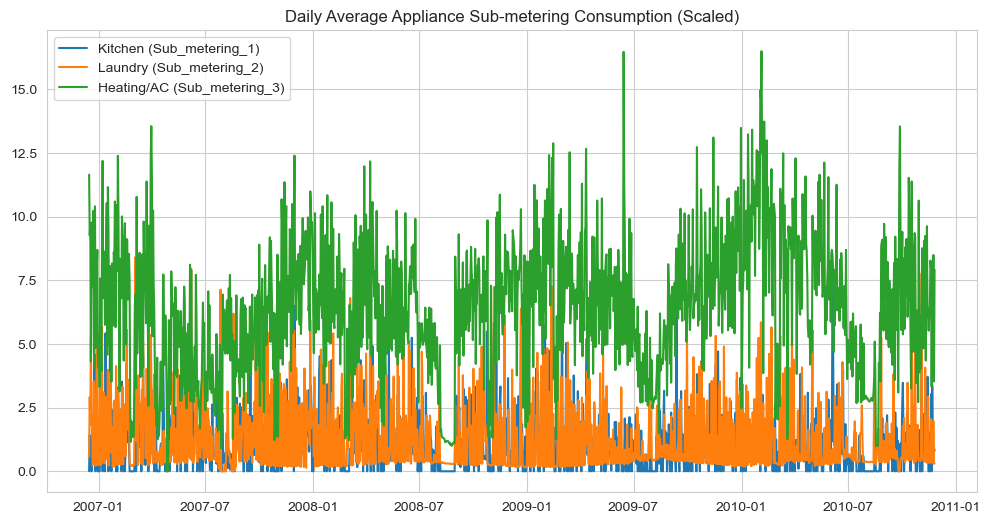

Average Daily Usage per Appliance (Scaled):
Sub_metering_1   1.10890539
Sub_metering_2   1.28862836
Sub_metering_3   6.44497327
dtype: float64
Most energy-hungry appliance: Sub_metering_3


In [40]:
#Appliance-specific insights
# Calculate average daily consumption per sub-meter (in scaled terms)

daily_consumption = hh_pwr_consum[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].resample('D').mean()

plt.figure(figsize=(12,6))
plt.plot(daily_consumption.index, daily_consumption['Sub_metering_1'], label='Kitchen (Sub_metering_1)')
plt.plot(daily_consumption.index, daily_consumption['Sub_metering_2'], label='Laundry (Sub_metering_2)')
plt.plot(daily_consumption.index, daily_consumption['Sub_metering_3'], label='Heating/AC (Sub_metering_3)')
plt.legend()
plt.title('Daily Average Appliance Sub-metering Consumption (Scaled)')
plt.show()

# Identify the most energy-hungry device based on mean usage
avg_usage = daily_consumption.mean()
print("Average Daily Usage per Appliance (Scaled):")
print(avg_usage)
print("Most energy-hungry appliance:", avg_usage.idxmax())

In [41]:
#Recommendations based on peak demand and usage

# Peak hours by average consumption
hourly_consumption = hh_pwr_consum.groupby('Hour')['Global_active_power'].mean()

peak_hours = hourly_consumption.sort_values(ascending=False).head(3).index.tolist()
print("Peak demand hours:", peak_hours)

print("""
Recommendations:
- Reduce energy consumption during peak hours: {}
- Use high-energy appliances during off-peak hours to save costs.
- Monitor appliance usage, especially {} which consumes the most energy.
- Consider using energy-efficient devices or scheduling to optimize usage.
""".format(peak_hours, avg_usage.idxmax()))

Peak demand hours: [20, 21, 19]

Recommendations:
- Reduce energy consumption during peak hours: [20, 21, 19]
- Use high-energy appliances during off-peak hours to save costs.
- Monitor appliance usage, especially Sub_metering_3 which consumes the most energy.
- Consider using energy-efficient devices or scheduling to optimize usage.

